# Eigenplaces for the Study Area — Temporal Typology of TAZs from 24-Hour Cellular Data

Adapts the *eigenplaces* idea of [Reades, Calabrese & Ratti (2009)](https://journals.sagepub.com/doi/abs/10.1068/b34133t) — eigendecomposition of places' normalized temporal activity signatures, validated against an independent land-use ground truth — to this study (see METHODOLOGY §8b for context). Their Erlang signals become **hourly trip-end profiles** from the cellular OD input, whose 24 hourly columns the pipeline has so far used only three of (h6–h8); their Pagine Gialle ground truth becomes the **2020 zonal demographics** (population, employment).

Two deliverables:

1. **A functional typology of the 778 study TAZs** from the *shape* (not volume) of their inbound/outbound daily rhythms: PCA of the signatures, k-means on the leading components, clusters labeled with demographics and mapped.
2. **A test of open caveat §8.3**: the one structural survey↔cellular disagreement is intra-zone self-containment (see the PCA notebooks). If it is caused by short local trips invisible to cell towers, the gap should concentrate in residential zone types — the typology makes that testable.

**Requirements beyond the standard setup:** `git lfs pull` (the hourly cellular CSV and the keys table), `pip install pyshp scipy` (map rendering, k-means).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.vq import kmeans2
from scipy.stats import kruskal
import shapefile
import os

# palette (repo convention); direction colors: blue = outbound, orange = inbound
BLUE, ORANGE, AQUA, YELLOW = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'
INK, INK2, MUTED, GRID, AXIS = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.grid(True, color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    for s in ax.spines.values():
        s.set_color(AXIS)
    ax.tick_params(colors=INK2, labelsize=9)
    if title: ax.set_title(title, color=INK, fontsize=12)
    if xlabel: ax.set_xlabel(xlabel, color=INK2, fontsize=10)
    if ylabel: ax.set_ylabel(ylabel, color=INK2, fontsize=10)

os.makedirs('Output/figures', exist_ok=True)
def save_show(fig, name):
    fig.savefig(f'Output/figures/{name}', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

HOURS = [f'h{i}' for i in range(24)]
HRS = np.arange(24)

## 1. Hourly trip-end signatures per TAZ

For each study TAZ: the average-weekday hourly profile of **outbound** trip-ends (all flows originating in the TAZ, any destination) and **inbound** trip-ends (any origin). Each profile is normalized to sum to 1 — following the eigenplaces normalization, volume is scaled out so the analysis compares *rhythms*, and a TAZ's signature is the 48-vector [outbound shape ‖ inbound shape].

In [2]:
keys_raw = pd.read_csv('Input/Matrices/1270_02_09_2021_TAZ_North_keys.csv', encoding='windows-1255')
kd = keys_raw[['TAZ_1270', 'TAZ_NUMBER']].dropna(subset=['TAZ_NUMBER'])
kd['TAZ_NUMBER'] = kd['TAZ_NUMBER'].astype(int)
kd = kd.drop_duplicates('TAZ_NUMBER')

cell = pd.read_csv('Input/Matrices/AvgDayHourlyTrips201819_1270_weekday_v1.csv')
out_h = (cell.merge(kd.rename(columns={'TAZ_1270': 'fromZone', 'TAZ_NUMBER': 'taz'}), on='fromZone')
         .groupby('taz')[HOURS].sum())
in_h = (cell.merge(kd.rename(columns={'TAZ_1270': 'ToZone', 'TAZ_NUMBER': 'taz'}), on='ToZone')
        .groupby('taz')[HOURS].sum())
assert list(out_h.index) == list(in_h.index)

vol = out_h.sum(axis=1) + in_h.sum(axis=1)
out_s = out_h.div(out_h.sum(axis=1), axis=0)
in_s = in_h.div(in_h.sum(axis=1), axis=0)
sig = pd.concat([out_s, in_s], axis=1)
assert sig.notna().all().all()
taz = sig.index

print(f"{len(taz)} TAZs with complete 48-hour signatures")
print(f"daily trip-end volume per TAZ: median {vol.median():,.0f}, 5th pct {vol.quantile(.05):,.0f}, "
      f"min {vol.min():,.0f} ({(vol < 100).sum()} TAZs below 100)")

778 TAZs with complete 48-hour signatures
daily trip-end volume per TAZ: median 20,897, 5th pct 3,214, min 21 (5 TAZs below 100)


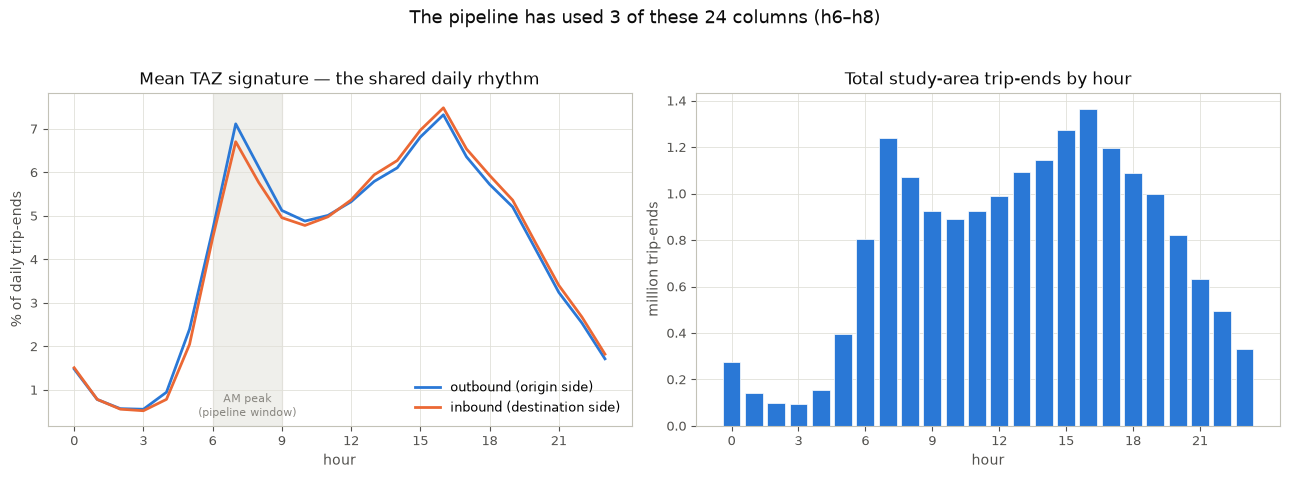

In [3]:
# the common rhythm (before any decomposition): mean shape + total volume by hour
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), facecolor='white')

ax = axes[0]
ax.plot(HRS, out_s.mean(axis=0) * 100, color=BLUE, linewidth=2, label='outbound (origin side)')
ax.plot(HRS, in_s.mean(axis=0) * 100, color=ORANGE, linewidth=2, label='inbound (destination side)')
ax.axvspan(6, 9, color=GRID, alpha=0.5, zorder=0)
ax.text(7.5, 0.4, 'AM peak\n(pipeline window)', ha='center', color=MUTED, fontsize=8)
ax.set_xticks(range(0, 24, 3))
style_ax(ax, 'Mean TAZ signature — the shared daily rhythm', 'hour', '% of daily trip-ends')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
ax.bar(HRS, (out_h.sum(axis=0) + in_h.sum(axis=0)) / 1e6, color=BLUE, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(0, 24, 3))
style_ax(ax, 'Total study-area trip-ends by hour', 'hour', 'million trip-ends')
fig.suptitle('The pipeline has used 3 of these 24 columns (h6–h8)', color=INK, fontsize=13, y=1.03)
plt.tight_layout()
save_show(fig, 'eigen_rhythm.png')

## 2. PCA of the signatures

Signatures are centered (the shared mean rhythm above is removed) and decomposed; components are therefore *deviations from the common rhythm* — the axes along which places differ. In the original eigenplaces (uncentered) formulation the first eigenvector is the common rhythm itself and the structure lives in the later components; centering gets to the structure directly.

explained variance: PC1 53.8%, PC2 12.1%, PC3 7.7%; 5 components reach 83%


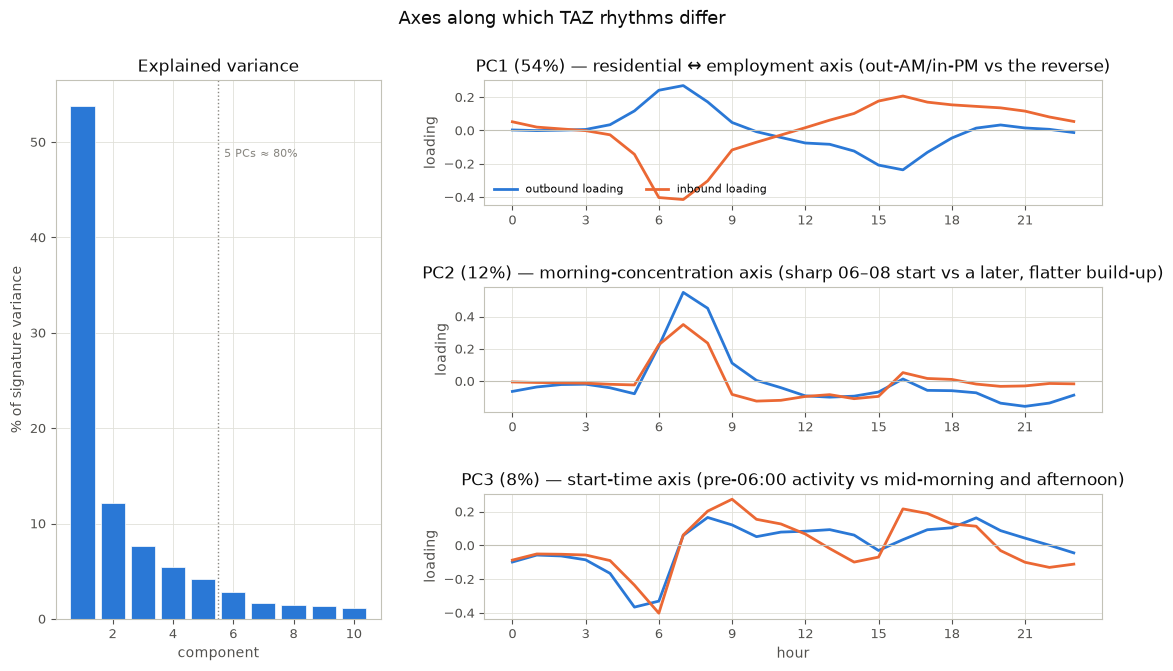

In [4]:
X = sig.values
mu = X.mean(axis=0)
U, s, Vt = np.linalg.svd(X - mu, full_matrices=False)
lam = s ** 2 / (len(X) - 1)
evr = lam / lam.sum()
scores = U * s
m80 = int(np.searchsorted(np.cumsum(evr), .8) + 1)
print(f"explained variance: PC1 {evr[0]:.1%}, PC2 {evr[1]:.1%}, PC3 {evr[2]:.1%}; "
      f"{m80} components reach {np.cumsum(evr)[m80-1]:.0%}")

interp = ['residential ↔ employment axis (out-AM/in-PM vs the reverse)',
          'morning-concentration axis (sharp 06–08 start vs a later, flatter build-up)',
          'start-time axis (pre-06:00 activity vs mid-morning and afternoon)']

fig = plt.figure(figsize=(13.5, 7), facecolor='white')
gs = fig.add_gridspec(3, 2, width_ratios=[1, 1.9], hspace=0.65, wspace=0.22)

ax = fig.add_subplot(gs[:, 0])
ax.bar(range(1, 11), evr[:10] * 100, color=BLUE, edgecolor='white', linewidth=0.5)
ax.axvline(m80 + 0.5, color=MUTED, linewidth=1, linestyle=':')
ax.text(m80 + 0.7, evr[0] * 90, f'{m80} PCs ≈ 80%', color=MUTED, fontsize=8)
style_ax(ax, 'Explained variance', 'component', '% of signature variance')

for j in range(3):
    ax = fig.add_subplot(gs[j, 1])
    ax.plot(HRS, Vt[j, :24], color=BLUE, linewidth=2, label='outbound loading')
    ax.plot(HRS, Vt[j, 24:], color=ORANGE, linewidth=2, label='inbound loading')
    ax.axhline(0, color=AXIS, linewidth=0.8)
    ax.set_xticks(range(0, 24, 3))
    style_ax(ax, f'PC{j+1} ({evr[j]:.0%}) — {interp[j]}', 'hour' if j == 2 else None, 'loading')
    if j == 0:
        ax.legend(frameon=False, fontsize=8, loc='lower left', ncols=2)
fig.suptitle('Axes along which TAZ rhythms differ', color=INK, fontsize=13, y=0.98)
save_show(fig, 'eigen_pca.png')

## 3. Clustering into a functional typology

k-means on the leading component scores. The inertia elbow and interpretability point to **k = 4**; the seed is fixed so the notebook is reproducible.

In [5]:
Z = scores[:, :m80]
for k in range(2, 9):
    cent_k, lab_k = kmeans2(Z, k, minit='++', seed=42)
    inertia = sum(((Z[lab_k == c] - cent_k[c]) ** 2).sum() for c in range(k))
    print(f"k={k}: inertia {inertia:.2f}, cluster sizes {sorted(np.bincount(lab_k, minlength=k), reverse=True)}")

K = 4
cent, lab = kmeans2(Z, K, minit='++', seed=42)
labels = pd.Series(lab, index=taz, name='cluster')

zon = pd.read_csv('Input/Zonal_2020.csv', encoding='windows-1255').set_index('TAZ_ID')
demo = labels.to_frame().join(zon[['POPULATION', 'EMPL_TOT', 'SOCECO', 'SECTOR_ARA']], how='left').join(vol.rename('volume'))
assert demo['POPULATION'].notna().all()
jpr = demo.groupby('cluster').apply(lambda d: d['EMPL_TOT'].sum() / d['POPULATION'].sum())

# display order: by jobs per resident, descending; names assigned from the profiles below
order = list(jpr.sort_values(ascending=False).index)
NAME = {order[0]: 'Employment cores', order[1]: 'Mixed / local centres',
        order[2]: 'Residential — peaked commuter', order[3]: 'Residential — diffuse rhythm'}
COLOR = {order[0]: BLUE, order[1]: ORANGE, order[2]: AQUA, order[3]: YELLOW}
for c in order:
    print(f"cluster {c} -> {NAME[c]} (n = {(lab == c).sum()}, jobs/resident = {jpr[c]:.2f})")

k=2: inertia 2.49, cluster sizes [np.int64(557), np.int64(221)]
k=3: inertia 2.07, cluster sizes [np.int64(391), np.int64(223), np.int64(164)]
k=4: inertia 1.66, cluster sizes [np.int64(273), np.int64(231), np.int64(185), np.int64(89)]
k=5: inertia 1.53, cluster sizes [np.int64(227), np.int64(212), np.int64(177), np.int64(87), np.int64(75)]
k=6: inertia 1.37, cluster sizes [np.int64(217), np.int64(206), np.int64(170), np.int64(95), np.int64(75), np.int64(15)]
k=7: inertia 1.30, cluster sizes [np.int64(206), np.int64(161), np.int64(149), np.int64(141), np.int64(80), np.int64(33), np.int64(8)]
k=8: inertia 1.16, cluster sizes [np.int64(170), np.int64(166), np.int64(151), np.int64(136), np.int64(80), np.int64(34), np.int64(33), np.int64(8)]
cluster 3 -> Employment cores (n = 89, jobs/resident = 3.59)
cluster 1 -> Mixed / local centres (n = 231, jobs/resident = 0.49)
cluster 2 -> Residential — peaked commuter (n = 273, jobs/resident = 0.24)
cluster 0 -> Residential — diffuse rhythm (n = 18

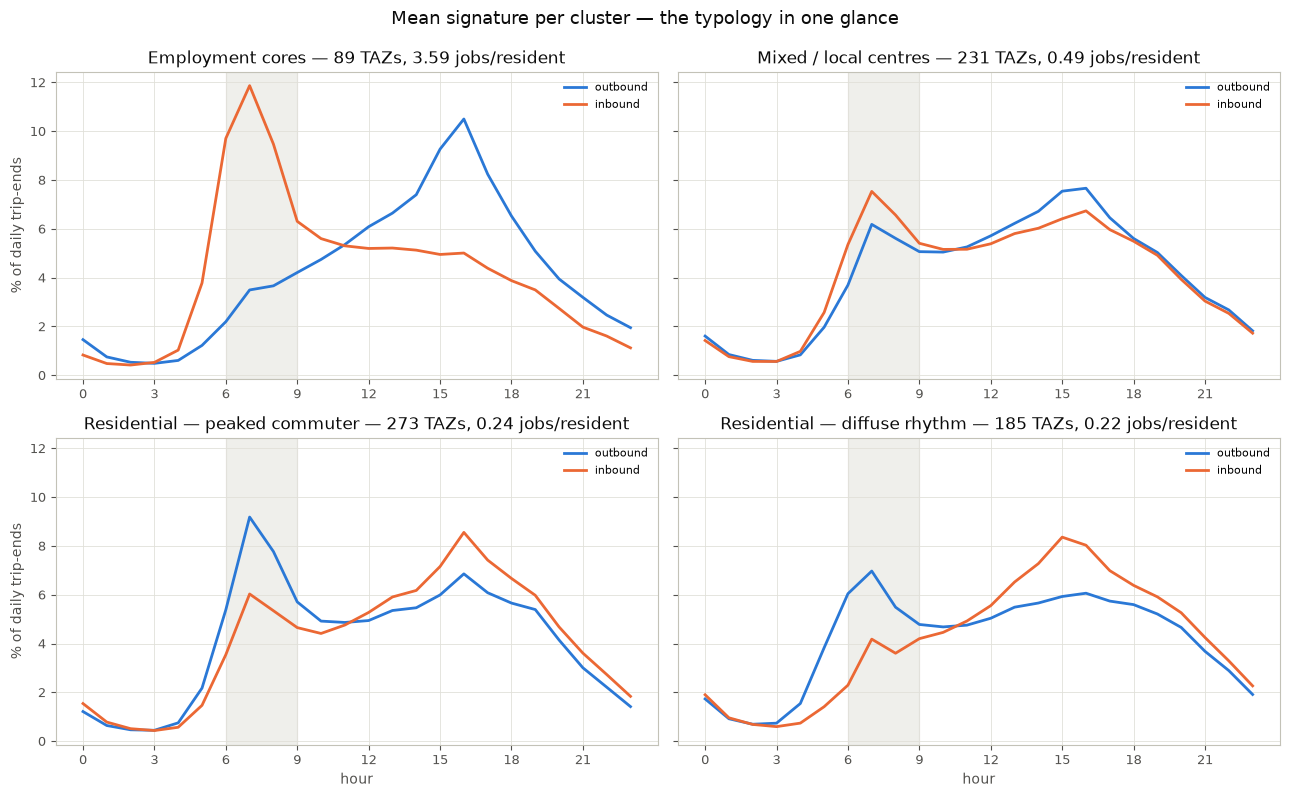

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), facecolor='white', sharey=True)
for ax, c in zip(axes.flat, order):
    m = sig[lab == c].mean(axis=0).values
    ax.plot(HRS, m[:24] * 100, color=BLUE, linewidth=2, label='outbound')
    ax.plot(HRS, m[24:] * 100, color=ORANGE, linewidth=2, label='inbound')
    ax.axvspan(6, 9, color=GRID, alpha=0.5, zorder=0)
    ax.set_xticks(range(0, 24, 3))
    n = (lab == c).sum()
    style_ax(ax, f'{NAME[c]} — {n} TAZs, {jpr[c]:.2f} jobs/resident',
             'hour' if ax in axes[1] else None,
             '% of daily trip-ends' if ax in axes[:, 0] else None)
    ax.legend(frameon=False, fontsize=8)
fig.suptitle('Mean signature per cluster — the typology in one glance', color=INK, fontsize=13, y=0.99)
plt.tight_layout()
save_show(fig, 'eigen_cluster_signatures.png')

## 4. Demographic ground truth

The clusters were built from cellular rhythms alone; the 2020 zonal file provides the independent check (the role Pagine Gialle played in the original paper).

,TAZs,population,employment,jobs per resident,mean socioeconomic idx,Arab-sector share
name,,,,,,
Employment cores,89,57511,206323,3.59,1.49,0.11
Mixed / local centres,231,642201,315007,0.49,4.50,0.10
Residential — peaked commuter,273,928114,226141,0.24,5.40,0.11
Residential — diffuse rhythm,185,911269,199060,0.22,3.39,0.74


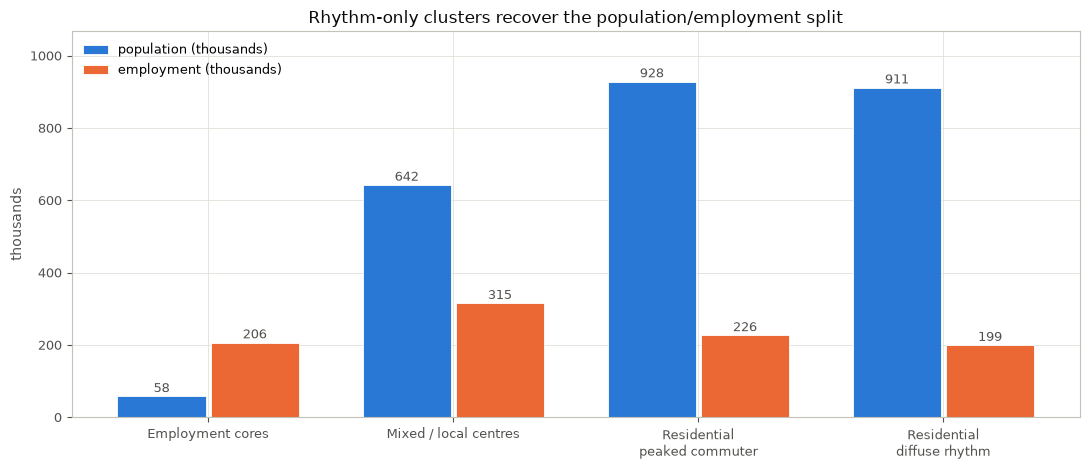

In [7]:
summary = pd.DataFrame({
    'name': {c: NAME[c] for c in order},
    'TAZs': demo.groupby('cluster').size(),
    'population': demo.groupby('cluster')['POPULATION'].sum(),
    'employment': demo.groupby('cluster')['EMPL_TOT'].sum(),
    'jobs per resident': jpr,
    'mean socioeconomic idx': demo.groupby('cluster')['SOCECO'].mean(),
    'Arab-sector share': demo.groupby('cluster')['SECTOR_ARA'].mean(),
}).loc[order].set_index('name')
display(summary.round(2))

x = np.arange(K)
fig, ax = plt.subplots(figsize=(11, 4.8), facecolor='white')
b1 = ax.bar(x - 0.19, [summary['population'].iloc[i] / 1e3 for i in range(K)], width=0.36,
            color=BLUE, edgecolor='white', linewidth=0.6, label='population (thousands)')
b2 = ax.bar(x + 0.19, [summary['employment'].iloc[i] / 1e3 for i in range(K)], width=0.36,
            color=ORANGE, edgecolor='white', linewidth=0.6, label='employment (thousands)')
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 12, f'{b.get_height():,.0f}',
                ha='center', color=INK2, fontsize=9)
ax.set_xticks(x, [NAME[c].replace(' — ', '\n') for c in order], fontsize=9)
ax.set_ylim(0, summary[['population', 'employment']].values.max() / 1e3 * 1.15)
style_ax(ax, 'Rhythm-only clusters recover the population/employment split', None, 'thousands')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
save_show(fig, 'eigen_cluster_demographics.png')

## 5. Map

Each panel highlights one cluster (identity is carried by the panel title and its color; the rest of the study area is gray).

shapefile: 781 TAZ geometries; 778 match the signature set


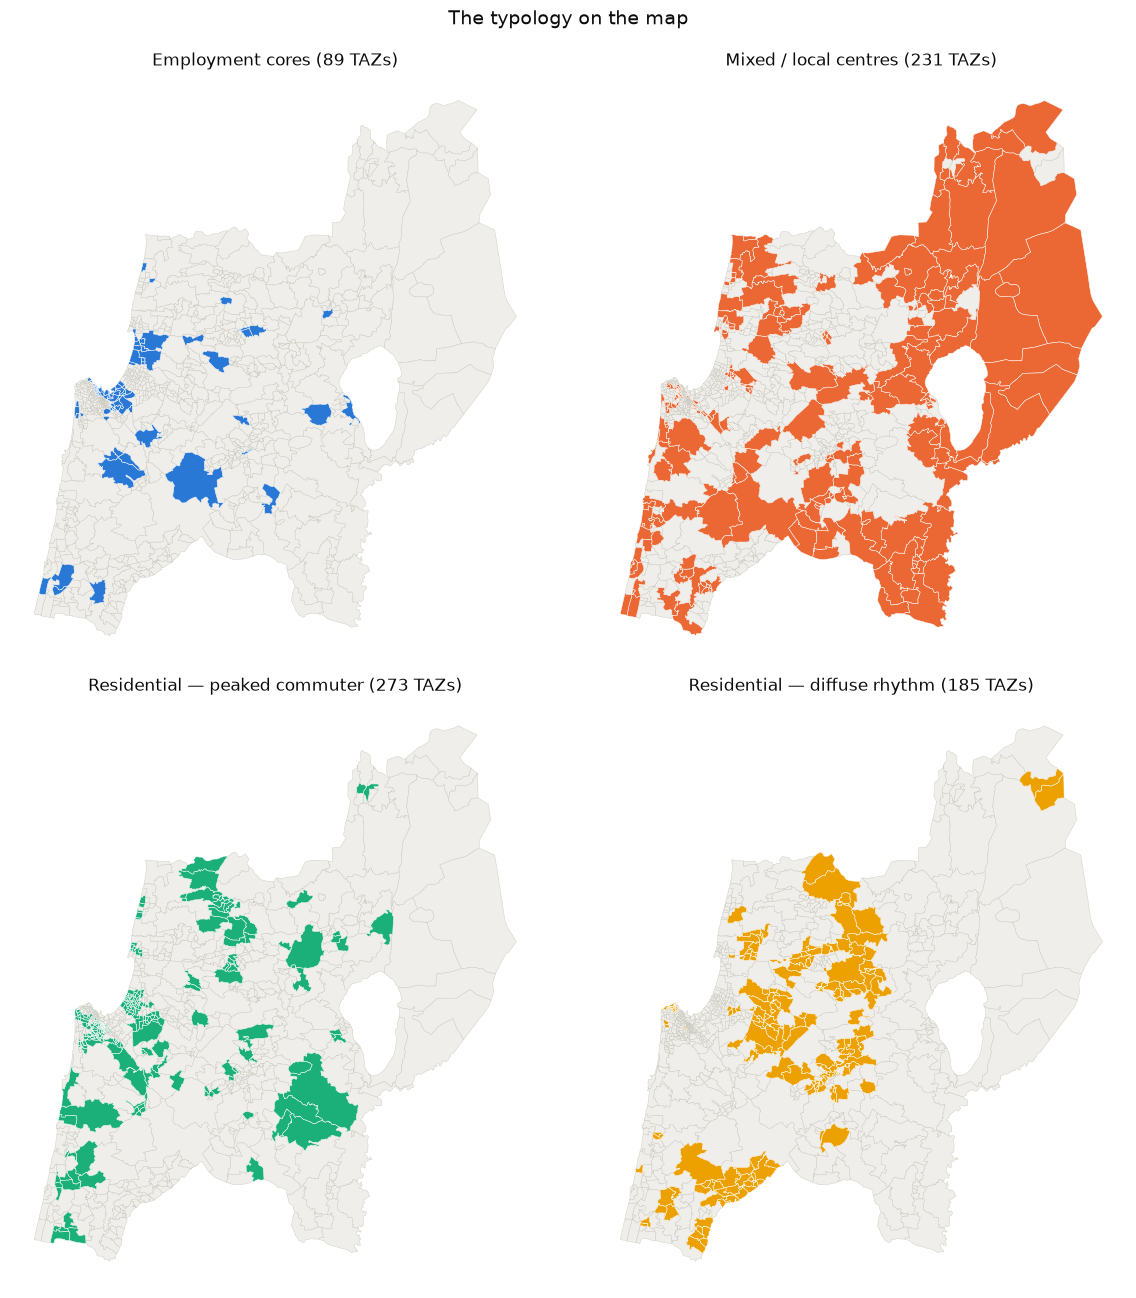

In [8]:
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection

sf = shapefile.Reader('Input/Demographic_Forecast/TAZ_shp/TAZ North.shp')
shapes, recs = sf.shapes(), sf.records()
taz_shapes = {}
for shp, rec in zip(shapes, recs):
    pts = np.array(shp.points)
    parts = list(shp.parts) + [len(pts)]
    taz_shapes.setdefault(rec['TAZ_NUMBER'], []).extend(
        pts[parts[i]:parts[i + 1]] for i in range(len(parts) - 1))
print(f"shapefile: {len(taz_shapes)} TAZ geometries; {len(set(taz_shapes) & set(taz))} match the signature set")

fig, axes = plt.subplots(2, 2, figsize=(12, 13), facecolor='white')
for ax, c in zip(axes.flat, order):
    in_cluster = set(taz[lab == c])
    base, hot = [], []
    for t, polys in taz_shapes.items():
        for p in polys:
            (hot if t in in_cluster else base).append(MplPolygon(p))
    ax.add_collection(PatchCollection(base, facecolor='#efeeea', edgecolor=AXIS, linewidth=0.25))
    ax.add_collection(PatchCollection(hot, facecolor=COLOR[c], edgecolor='white', linewidth=0.35))
    ax.autoscale()
    ax.set_aspect('equal')
    ax.set_axis_off()
    ax.set_title(f'{NAME[c]} ({(lab == c).sum()} TAZs)', color=INK, fontsize=12)
fig.suptitle('The typology on the map', color=INK, fontsize=14, y=0.995)
plt.tight_layout()
save_show(fig, 'eigen_cluster_map.png')

## 6. The self-containment gap, by cluster — testing caveat §8.3

The PCA comparison notebooks established that the one structural survey↔cellular disagreement is intra-zone self-containment, and METHODOLOGY §8.3 hypothesizes short local trips invisible to cell towers as the cause. If that is right, the gap should concentrate where short local trips concentrate — residential zones — and be small in employment cores, where commuters have already registered a long inter-zonal trip by arriving. Per TAZ (where the survey observed any trips): survey self-containment from the 2017 trips-file matrix minus cellular AM self-containment.

TAZs with both measures: 730; overall mean gap +0.114


,n,survey,cellular,gap,gap_median,gap_volume_weighted
Employment cores,83,0.149,0.058,0.091,0.034,0.055
Mixed / local centres,208,0.189,0.073,0.116,0.047,0.102
Residential — peaked commuter,266,0.138,0.060,0.078,0.034,0.064
Residential — diffuse rhythm,173,0.212,0.034,0.177,0.154,0.144


Kruskal–Wallis across clusters: H = 69.6, p = 5.2e-15


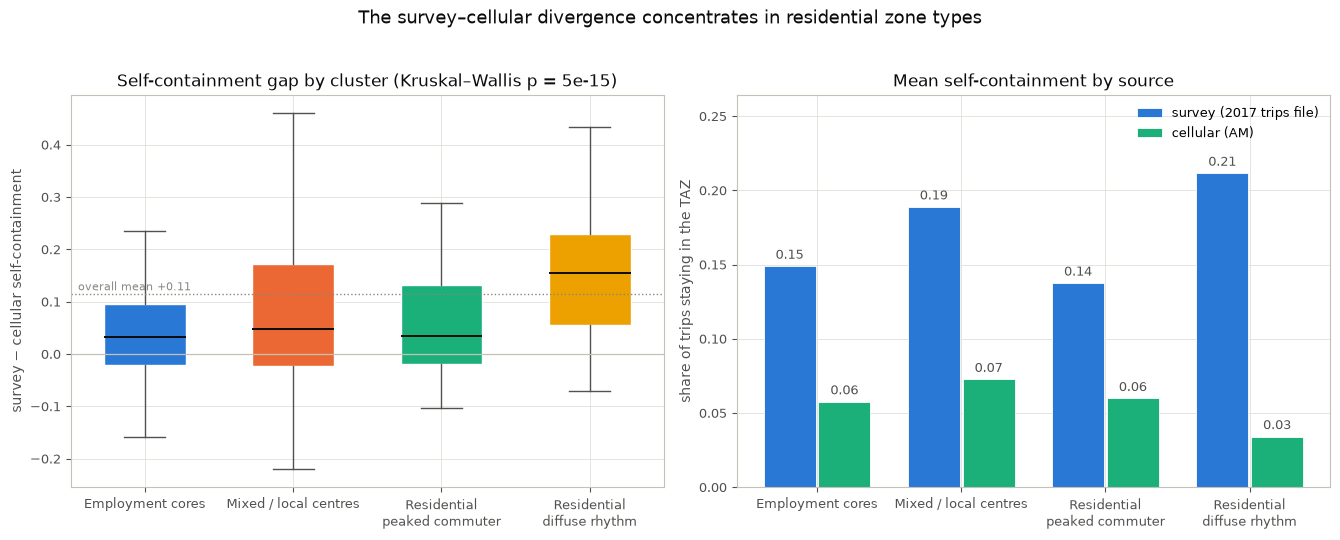

In [9]:
surv = pd.read_csv('Output/ths2017/study_taz/matrix_avg_ALL_taz.csv', index_col=0)
surv.columns = surv.columns.astype(int)
rs = surv.sum(axis=1)
surv_self = (pd.Series(np.diag(surv.values), index=surv.index)[rs > 0] / rs[rs > 0]).rename('survey')

cellp = pd.read_csv('Output/prob_matrix_cellular.csv', index_col=0)
cellp.columns = cellp.columns.astype(int)
cell_self = pd.Series(np.diag(cellp.values), index=cellp.index).rename('cellular')

gd = (labels.to_frame().join(surv_self, how='inner').join(cell_self)
      .join(vol.rename('volume')).dropna())
gd['gap'] = gd['survey'] - gd['cellular']
print(f"TAZs with both measures: {len(gd)}; overall mean gap {gd['gap'].mean():+.3f}")

stats = gd.groupby('cluster').agg(n=('gap', 'size'), survey=('survey', 'mean'),
                                  cellular=('cellular', 'mean'), gap=('gap', 'mean'),
                                  gap_median=('gap', 'median'))
stats['gap_volume_weighted'] = gd.groupby('cluster').apply(lambda d: np.average(d['gap'], weights=d['volume']))
stats.index = [NAME[c] for c in stats.index]
display(stats.loc[[NAME[c] for c in order]].round(3))

groups = [gd.loc[gd['cluster'] == c, 'gap'].values for c in order]
H, p = kruskal(*groups)
print(f"Kruskal–Wallis across clusters: H = {H:.1f}, p = {p:.1e}")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), facecolor='white')

ax = axes[0]
bp = ax.boxplot(groups, patch_artist=True, widths=0.55, showfliers=False,
                medianprops=dict(color=INK, linewidth=1.4))
for patch, c in zip(bp['boxes'], order):
    patch.set_facecolor(COLOR[c]); patch.set_edgecolor('white')
for el in ('whiskers', 'caps'):
    for l in bp[el]: l.set_color(INK2)
ax.axhline(0, color=AXIS, linewidth=0.9)
ax.axhline(gd['gap'].mean(), color=MUTED, linewidth=1, linestyle=':')
ax.text(0.55, gd['gap'].mean() + 0.008, f"overall mean {gd['gap'].mean():+.2f}", color=MUTED, fontsize=8)
ax.set_xticks(range(1, K + 1), [NAME[c].replace(' — ', '\n') for c in order], fontsize=9)
style_ax(ax, f'Self-containment gap by cluster (Kruskal–Wallis p = {p:.0e})',
         None, 'survey − cellular self-containment')

ax = axes[1]
x = np.arange(K)
b1 = ax.bar(x - 0.19, [stats.loc[NAME[c], 'survey'] for c in order], width=0.36,
            color=BLUE, edgecolor='white', linewidth=0.6, label='survey (2017 trips file)')
b2 = ax.bar(x + 0.19, [stats.loc[NAME[c], 'cellular'] for c in order], width=0.36,
            color=AQUA, edgecolor='white', linewidth=0.6, label='cellular (AM)')
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.005, f'{b.get_height():.2f}',
                ha='center', color=INK2, fontsize=9)
ax.set_xticks(x, [NAME[c].replace(' — ', '\n') for c in order], fontsize=9)
ax.set_ylim(0, max(stats['survey'].max(), stats['cellular'].max()) * 1.25)
style_ax(ax, 'Mean self-containment by source', None, 'share of trips staying in the TAZ')
ax.legend(frameon=False, fontsize=9)
fig.suptitle('The survey–cellular divergence concentrates in residential zone types',
             color=INK, fontsize=13, y=1.03)
plt.tight_layout()
save_show(fig, 'eigen_selfcontainment_gap.png')

In [10]:
# side check: how mixed are the SZ_NEW superzones in terms of clusters?
taz_to_sz = keys_raw[['TAZ_NUMBER', 'SZ_NEW']].dropna().astype(int).drop_duplicates('TAZ_NUMBER').set_index('TAZ_NUMBER')['SZ_NEW']
mix = labels.to_frame().join(taz_to_sz.rename('sz'), how='inner').groupby('sz')['cluster'].nunique()
print(f"of {len(mix)} superzones: {(mix == 1).sum()} contain a single cluster, "
      f"{(mix == 2).sum()} two, {(mix >= 3).sum()} three or more")

of 36 superzones: 2 contain a single cluster, 11 two, 23 three or more


## 7. Findings

**1. Daily rhythms alone recover the functional structure of the study area.** Four types emerge from the shape of the 24-hour cellular signatures — with no demographic input — and the independent 2020 zonal file confirms them: **employment cores** (89 TAZs, 3.59 jobs/resident — 22% of the study area's employment on 2.3% of its population), **mixed / local centres** (231 TAZs, 0.49), and two residential types (0.22–0.24). The leading axis of variation (PC1, 54% of signature variance) is exactly the residential ↔ employment dimension: outbound-morning/inbound-afternoon vs the reverse. This replicates the eigenplaces result — telecom rhythm recovers land use — on trip-end data.

**2. The two residential types differ by rhythm, and the split tracks a known community distinction.** "Peaked commuter" zones (273 TAZs) concentrate 9.2% of daily outbound trip-ends in hour 7 with a sharp inbound return at 16:00–17:00; "diffuse rhythm" zones (185 TAZs) spread activity almost flatly through the day (outbound peak only 7.0%). The diffuse cluster is 74% Arab-sector localities (vs ~10–11% in every other cluster), i.e. the rhythm typology independently recovers the locally-oriented, all-day travel pattern the THS documents for these communities. (The socioeconomic index column reflects resident population and is not meaningful for the near-unpopulated employment cores.)

**3. The self-containment gap concentrates exactly where the short-local-trips hypothesis predicts (caveat §8.3).** Across 730 TAZs the survey−cellular self-containment gap averages +0.114, but it is far from uniform (Kruskal–Wallis p ≈ 5×10⁻¹⁵): **diffuse-rhythm residential zones show survey 21.2% vs cellular 3.4%** — a mean gap of +0.177 (volume-weighted +0.144) — while employment cores show the smallest weighted gap (+0.055) and peaked-commuter residential +0.064. Where life is local, the survey reports the most intra-zone travel and the cellular data records almost none of it; where trips are long commutes, the two sources nearly agree. This turns §8.3 from a hypothesis into quantified, spatially resolved evidence, and makes **functional-type-conditioned correction factors** a well-founded refinement of the EB step.

**4. The superzone aggregation blurs across types.** 23 of 36 `SZ_NEW` superzones contain three or more functional types, so a single superzone correction factor currently averages over zone types whose gaps differ by a factor of ~2.6 (0.055 vs 0.144 weighted). A type-aware correction — or at minimum awareness of each superzone's type mix — would sharpen the hybrid exactly where it matters.

**5. Further uses now available cheaply:** the cluster labels are a candidate stratum for the mode-share EB smoothing (alongside corridor class × distance band); station-catchment signatures for the LRT alignments would show whether the line serves a one-directional commuter peak or balanced all-day demand; and per-type AM→daily factors follow directly from the signatures if the forecast ever needs periods beyond 6–9.

**Caveats.** The cellular file is an average weekday, so the weekday/weekend axis of the original eigenplaces is unavailable; signatures are shapes, so very small zones are noisier (only 5 TAZs below 100 daily trip-ends); the TAZ-level survey diagonal is sparse (medians well below means — hence the nonparametric test and volume-weighted summaries); and cellular self-containment inherits the short-trip blindness everywhere, so the *level* of the gap is informative mainly in comparison across types, not absolutely.